In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pytorch-tabnet torch

In [ ]:
!pip install catboost lightgbm pytorch-tabnet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import requests
import time
from datetime import timedelta
from prophet import Prophet
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from pytorch_tabnet.tab_model import TabNetRegressor
from pytorch_tabnet.pretraining import TabNetPretrainer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# --- 路徑 ---
DATA_PATH = "/content/drive/MyDrive/SideProject/用機器學習預測台灣珊瑚礁覆蓋面積/珊瑚礁/ReefCheckTaiwan_2009_2020_data.csv"
SITE_PATH = "/content/drive/MyDrive/SideProject/用機器學習預測台灣珊瑚礁覆蓋面積/珊瑚礁/ReefCheckTaiwan_2009_2020_site.csv"

# 定義珊瑚覆蓋面積組成
CORAL_COMPONENTS = ['HC', 'SC', 'RKC']
# 原本資料集的基礎特徵清單 (排除目標變數)
BASE_FEATURES = [
    'NIA', 'SP', 'Butterflyfish', 'Haemulidae', 'Snapper', 'BarramundiCod',
    'HumpheadWrasse', 'BumpheadParrotfish', 'Parrotfish', 'MoralEel',
    'Grouper_XS', 'Grouper_S', 'Grouper_M', 'Grouper_L', 'Total_fish',
    'BandedCoralShrimp', 'Diadema', 'PencilUrchin', 'CollectorUrchin',
    'SeaCucumber', 'COTS', 'Triton', 'Lobster', 'GiantClam_XS',
    'GiantClam_S', 'GiantClam_M', 'GiantClam_L', 'GiantClam_XL', 'GiantClam_XXL'
]

In [ ]:
def load_and_preprocess():
    data = pd.read_csv(DATA_PATH)
    data_site = pd.read_csv(SITE_PATH)

    # 選擇需要的欄位
    cols = ['Date', 'Site'] + CORAL_COMPONENTS + BASE_FEATURES
    df = data[cols].copy()

    # 合併經緯度
    df = pd.merge(df, data_site[['Site', 'Latitude', 'Longitude']], on='Site', how='left')
    df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d', errors='coerce')
    df.dropna(subset=['Latitude', 'Longitude', 'Date'], inplace=True)
    df['Year'] = df['Date'].dt.year

    # 建立座標對照表 (用於 API 抓取)
    site_coords = {
        'YeLiu': [25.21, 121.69], 'TidalPark': [25.14, 121.78], 'FanCaiao': [25.13, 121.82],
        'BiTou': [25.12, 121.91], 'LongDong1.5': [25.11, 121.91], 'LongDong4': [25.10, 121.92],
        'ShiTiPing': [23.48, 121.51], 'GiHaw': [23.11, 121.39], 'ShanYuan': [22.82, 121.19],
        'HeChei': [22.81, 121.20], 'ChaiKou': [22.68, 121.48], 'GongGuan': [22.68, 121.50],
        'JiangJunYan': [22.68, 121.50], 'DaBaiSha': [22.64, 121.48], 'ShiLang': [22.66, 121.47],
        'TurtleBay': [22.33, 120.35], 'BeautyRock': [22.35, 120.37], 'HenRock': [22.33, 120.37],
        'LionSouth': [22.34, 120.37], 'HouShi': [22.32, 120.36], 'BeautyCave': [22.35, 120.36],
        'YuChenWei': [22.35, 120.38], 'EasternIsletS': [23.25, 119.51],
        'EasternIsletE': [23.26, 119.52], 'EasternIsletW': [23.25, 119.50]
    }
    return df, site_coords

def classify_coast(df):
    east_sites = ['YeLiu', 'TidalPark', 'FanCaiao', 'BiTou', 'LongDong1.5', 'LongDong4',
                  'ShiTiPing', 'GiHaw', 'ShanYuan', 'HeChei', 'ChaiKou', 'GongGuan',
                  'JiangJunYan', 'DaBaiSha', 'ShiLang']
    df['Coast'] = df['Site'].apply(lambda x: 'East' if x in east_sites else 'West')
    return pd.get_dummies(df, columns=['Coast'], prefix='Is')

df_main, site_coords = load_and_preprocess()
df_main = classify_coast(df_main)

In [ ]:
# 建立地區座標對照表
site_coords = {
    # 東北角海域
    'YeLiu': [25.21, 121.69], 'TidalPark': [25.14, 121.78], 'FanCaiao': [25.13, 121.82],
    'BiTou': [25.12, 121.91], 'LongDong1.5': [25.11, 121.91], 'LongDong4': [25.10, 121.92],
    # 東部海域
    'ShiTiPing': [23.48, 121.51], 'GiHaw': [23.11, 121.39], 'ShanYuan': [22.82, 121.19], 'HeChei': [22.81, 121.20],
    # 綠島 (Green Island)
    'ChaiKou': [22.68, 121.48], 'GongGuan': [22.68, 121.50], 'JiangJunYan': [22.68, 121.50],
    'DaBaiSha': [22.64, 121.48], 'ShiLang': [22.66, 121.47],
    # 小琉球 (Xiao Liu Qiu)
    'TurtleBay': [22.33, 120.35], 'BeautyRock': [22.35, 120.37], 'HenRock': [22.33, 120.37],
    'LionSouth': [22.34, 120.37], 'HouShi': [22.32, 120.36], 'BeautyCave': [22.35, 120.36], 'YuChenWei': [22.35, 120.38],
    # 東嶼坪 (Eastern Islet - 南方四島)
    'EasternIsletS': [23.25, 119.51], 'EasternIsletE': [23.26, 119.52], 'EasternIsletW': [23.25, 119.50]
}

# 將座標對應回您的 dataframe
# 假設您的主 DataFrame 叫 df
df['lat'] = df['Site'].map(lambda x: site_coords.get(x, [None, None])[0])
df['lon'] = df['Site'].map(lambda x: site_coords.get(x, [None, None])[1])

In [ ]:
import requests
import pandas as pd
import numpy as np
from datetime import timedelta
import time

def get_climate_open_meteo(df):
    unique_surveys = df[['Site', 'Date']].drop_duplicates().copy()
    avg_temps = []
    total_rains = []

    print(f"📡 正在從 Open-Meteo 抓取 {len(unique_surveys)} 筆氣候資料...")

    for idx, row in unique_surveys.iterrows():
        site = row['Site']
        end_date = row['Date']
        start_date = end_date - timedelta(days=30)

        lat, lon = site_coords.get(site, [None, None])
        if lat is None:
            avg_temps.append(np.nan); total_rains.append(np.nan)
            continue

        # Open-Meteo 格式: YYYY-MM-DD
        s_str = start_date.strftime('%Y-%m-%d')
        e_str = end_date.strftime('%Y-%m-%d')

        # 使用 Open-Meteo 歷史/存檔 API
        url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={s_str}&end_date={e_str}&daily=temperature_2m_mean,precipitation_sum&timezone=GMT"

        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                res = response.json()
                temp_list = res['daily']['temperature_2m_mean']
                rain_list = res['daily']['precipitation_sum']

                # 清洗 None 值（API 有時會回傳 null）
                temp_list = [t for t in temp_list if t is not None]
                rain_list = [r for r in rain_list if r is not None]

                avg_temps.append(np.mean(temp_list) if temp_list else np.nan)
                total_rains.append(np.sum(rain_list) if rain_list else np.nan)
                print(f"✅ {site} ({e_str}) 抓取成功")
            else:
                print(f"❌ {site} 失敗: 狀態碼 {response.status_code}")
                avg_temps.append(np.nan); total_rains.append(np.nan)
        except:
            print(f"⚠️ {site} 連線異常")
            avg_temps.append(np.nan); total_rains.append(np.nan)

        time.sleep(0.2) # Open-Meteo 速度很快，不需要等太久

    unique_surveys['Avg_Temp_30d'] = avg_temps
    unique_surveys['Total_Rain_30d'] = total_rains
    return df.merge(unique_surveys, on=['Site', 'Date'], how='left')

# 執行抓取
data_with_weather = get_climate_open_meteo(df)

# 顯示前幾筆確認
print("\n--- 抓取結果預覽 ---")
print(data_with_weather[['Site', 'Date', 'Avg_Temp_30d', 'Total_Rain_30d']].dropna().head())

📡 正在從 Open-Meteo 抓取 178 筆氣候資料...
✅ YeLiu (2009-06-13) 抓取成功
✅ YeLiu (2010-07-04) 抓取成功
✅ YeLiu (2011-08-21) 抓取成功
✅ YeLiu (2012-07-01) 抓取成功
✅ YeLiu (2013-09-15) 抓取成功
✅ YeLiu (2014-08-17) 抓取成功
✅ YeLiu (2015-08-16) 抓取成功
✅ YeLiu (2016-05-15) 抓取成功
✅ YeLiu (2016-08-13) 抓取成功
✅ YeLiu (2017-08-13) 抓取成功
✅ YeLiu (2018-05-20) 抓取成功
✅ YeLiu (2019-05-12) 抓取成功
✅ YeLiu (2020-07-11) 抓取成功
✅ TidalPark (2017-08-19) 抓取成功
✅ TidalPark (2018-08-19) 抓取成功
✅ TidalPark (2019-06-02) 抓取成功
✅ TidalPark (2020-06-27) 抓取成功
✅ FanCaiao (2009-06-13) 抓取成功
✅ FanCaiao (2010-07-17) 抓取成功
✅ FanCaiao (2011-08-20) 抓取成功
✅ FanCaiao (2012-06-09) 抓取成功
✅ FanCaiao (2013-07-28) 抓取成功
✅ FanCaiao (2014-07-05) 抓取成功
✅ FanCaiao (2015-09-23) 抓取成功
✅ FanCaiao (2016-05-29) 抓取成功
✅ FanCaiao (2017-07-01) 抓取成功
✅ FanCaiao (2018-07-07) 抓取成功
✅ FanCaiao (2019-07-10) 抓取成功
✅ FanCaiao (2020-07-25) 抓取成功
✅ BiTou (2009-05-23) 抓取成功
✅ BiTou (2010-07-11) 抓取成功
✅ BiTou (2011-08-14) 抓取成功
✅ BiTou (2012-07-28) 抓取成功
✅ BiTou (2013-07-27) 抓取成功
✅ BiTou (2014-06-14) 抓取成功
✅ BiT

In [ ]:
def classify_coast_by_site(site):
    east_sites = [
        'YeLiu', 'TidalPark', 'FanCaiao', 'BiTou', 'LongDong1.5', 'LongDong4', # 東北角
        'ShiTiPing', 'GiHaw', 'ShanYuan', 'HeChei', # 東部
        'ChaiKou', 'GongGuan', 'JiangJunYan', 'DaBaiSha', 'ShiLang' # 綠島
    ]
    # 澎湖、小琉球歸類為西海岸或獨立一類
    if site in east_sites:
        return 'East'
    else:
        return 'West'

# 應用到 DataFrame
df['Coast'] = df['Site'].apply(classify_coast_by_site)

# 進行 One-Hot Encoding
df = pd.get_dummies(df, columns=['Coast'], prefix='Is')

In [ ]:
from prophet import Prophet

def add_prophet_features(df):
    df = df.sort_values(['Site', 'Date'])
    all_sites_preds = []

    for site in df['Site'].unique():
        site_data = df[df['Site'] == site].copy()
        if len(site_data) < 5: # 數據太少無法訓練 Prophet 的話就跳過
            site_data['prophet_pred'] = site_data['HC'] + site_data['SC'] + site_data['RKC'] # 用原值代替
            all_sites_preds.append(site_data)
            continue

        # 準備 Prophet 格式
        m_df = pd.DataFrame({
            'ds': pd.to_datetime(site_data['Date']),
            'y': site_data['HC'] + site_data['SC'] + site_data['RKC']
        })

        m = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
        m.fit(m_df)

        # 取得歷史預測值
        forecast = m.predict(m_df)
        site_data['prophet_pred'] = forecast['yhat'].values
        all_sites_preds.append(site_data)

    return pd.concat(all_sites_preds)

# 應用在你的資料集上
data_with_weather = add_prophet_features(data_with_weather)

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
INFO:prophet:n_changepoints greater than number of observations. Using 16.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:n_changepoints greater than number of observations. Using 15.
INFO:prophet:n_changepoints greater than number of observations. Using 10.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


In [ ]:
# --- 插入在資料合併完成後 ---

def calculate_heat_stress(df, window=90):
    """
    計算累積熱壓力：當氣溫高於該地區歷史 90% 分位數時的累計值
    """
    df = df.sort_values(['Site', 'Date'])

    # 1. 找出各地區的基準溫 (Threshold)
    # 使用 30 天平均氣溫作為基準
    df['temp_threshold'] = df.groupby('Site')['Avg_Temp_30d'].transform(lambda x: x.quantile(0.90))

    # 2. 計算超出基準的溫差
    df['temp_excess'] = (df['Avg_Temp_30d'] - df['temp_threshold']).clip(lower=0)

    # 3. 計算過去 90 天的累積熱壓力 (Rolling Sum)
    df['accumulated_heat_stress'] = df.groupby('Site')['temp_excess'].transform(
        lambda x: x.rolling(window=window, min_periods=1).sum()
    )

    # 移除中間計算用的臨時欄位
    return df.drop(columns=['temp_threshold', 'temp_excess'])

# 應用計算
data_with_weather = calculate_heat_stress(data_with_weather)

# 記得在你的 Cell 10 的 new_features 裡面加入這個新特徵
# new_features = ['Avg_Temp_30d', 'Total_Rain_30d', 'accumulated_heat_stress']

In [ ]:
# 1. 首先計算目標變量 (Coral Cover)，方便產生它的滯後特徵
data_with_weather['Coral_Cover'] = data_with_weather['HC'] + data_with_weather['SC'] + data_with_weather['RKC']

# 2. 確保資料按地區與時間排序
data_with_weather = data_with_weather.sort_values(by=['Site', 'Date']).reset_index(drop=True)

# 3. 建立滯後特徵 (以地區為單位進行 shift)
# 我們可以建立「前一次調查」的珊瑚覆蓋率 (Lag_1)
data_with_weather['Lag_Coral_Cover'] = data_with_weather.groupby('Site')['Coral_Cover'].shift(1)

# 4. 處理缺失值
# 每個地區的第一筆資料會因為沒有「前一次」而產生 NaN
# 這裡建議直接刪除這些無法計算滯後特徵的初始樣本，或者用該地區的平均值填補
data_with_weather = data_with_weather.dropna(subset=['Lag_Coral_Cover'])

print("滯後特徵添加完成，目前的特徵包含: Lag_Coral_Cover")

滯後特徵添加完成，目前的特徵包含: Lag_Coral_Cover


In [ ]:


# 定義目標變數 (y = HC + SC + RKC) 並移除不必要欄位
# y = df['HC'] + df['SC'] + df['RKC']
y = data_with_weather['Coral_Cover']
new_features = ['Avg_Temp_30d', 'Total_Rain_30d']
current_features = [col for col in data_with_weather.columns if col not in ['HC', 'SC', 'RKC', 'Site', 'Date', 'Latitude', 'Longitude', 'Coral_Cover', 'lat', 'lon']]

# 處理遺失值 (填補平均值，避免模型報錯)
data_with_weather['Avg_Temp_30d'] = data_with_weather['Avg_Temp_30d'].fillna(data_with_weather['Avg_Temp_30d'].mean())
data_with_weather['Total_Rain_30d'] = data_with_weather['Total_Rain_30d'].fillna(data_with_weather['Total_Rain_30d'].mean())

# 更新 X 和 y
X = data_with_weather[current_features]

# 1. 確保資料按日期排序
data_with_weather = data_with_weather.sort_values(['Date'])

# 2. 找到切分點 (例如: 2021年以前為訓練, 2022年以後為測試)
# 或者簡單按比例切分，但不打破時間順序
train_size = int(len(data_with_weather) * 0.8)
train_df = data_with_weather.iloc[:train_size]
test_df = data_with_weather.iloc[train_size:]

X_train = train_df[current_features]
y_train = train_df['Coral_Cover']
X_test = test_df[current_features]
y_test = test_df['Coral_Cover']

# 這樣分割後，Lag_Coral_Cover 才有真正的預測意義

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

In [ ]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R2 : {r2:.4f}\n")
    return mae, mse, r2

def plot_results(y_true, y_pred, title):
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=range(len(y_true)), y=y_true, label='Actual', alpha=0.6)
    sns.lineplot(x=range(len(y_pred)), y=y_pred, label='Predicted', alpha=0.6)
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:
import torch
from pytorch_tabnet.pretraining import TabNetPretrainer
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import GridSearchCV

# 1. 執行自監督預訓練 (Self-supervised Pre-training)
# 這對應你圖片中的 Masking 與 Reconstruction 過程
unsupervised_model = TabNetPretrainer(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='sparsemax',
    seed=42
)

unsupervised_model.fit(
    X_train=X_train_scaled.values,
    eval_set=[X_test_scaled.values],
    max_epochs=100,
    patience=10,
    batch_size=128,
    virtual_batch_size=16,
    pretraining_ratio=0.8 # 遮蓋 80% 的特徵來讓模型練習預測
)


# 2. 設定 Grid Search 參數
param_grid_tabnet = {
    'n_d': [4, 8],
    'n_a': [4, 8],
    'n_steps': [2, 3],
    'gamma': [1.3, 1.5],
    'lambda_sparse': [1e-1, 1e-2],
    'momentum': [0.02, 0.05],
    'n_shared': [2],
    'n_independent': [2],

}

# 3. 定義 Grid Search
# 注意：我們在初始化 TabNetRegressor 時不直接傳入 pretrainer，
# 而是在 fit 的時候傳入
grid_tabnet = GridSearchCV(
    TabNetRegressor(verbose=0, seed=42),
    param_grid_tabnet,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=1  # 使用預訓練模型時，建議設為 1 以確保權重正確載入且避免顯存問題
)

# 4. 執行 fit (整合預訓練模型)
# 這裡使用 fit_params 將自監督學習的成果從 best_estimator 傳下去
grid_tabnet.fit(
    X_train_scaled.values,
    y_train.values.reshape(-1, 1),
    max_epochs=100,
    patience=10,
    batch_size=128,
    virtual_batch_size=16,
    from_unsupervised=unsupervised_model # 關鍵：將第一步學到的「特徵直覺」傳給 Regressor
)

# 5. 預測
y_pred_tabnet = grid_tabnet.best_estimator_.predict(X_test_scaled.values).flatten()

print(f"最佳參數: {grid_tabnet.best_params_}")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: -15.7046| val_0_unsup_loss_numpy: 24634799947776.0|  0:00:00s
epoch 1  | loss: -80.96837| val_0_unsup_loss_numpy: 126153071263744.0|  0:00:00s
epoch 2  | loss: -189.99494| val_0_unsup_loss_numpy: 117327559393280.0|  0:00:00s
epoch 3  | loss: -405.68142| val_0_unsup_loss_numpy: 168174276313088.0|  0:00:00s
epoch 4  | loss: -729.06947| val_0_unsup_loss_numpy: 6.564560729695846e+16|  0:00:01s
epoch 5  | loss: -1479.77033| val_0_unsup_loss_numpy: 642371616243712.0|  0:00:01s
epoch 6  | loss: -2242.14667| val_0_unsup_loss_numpy: 7.481666384900915e+16|  0:00:01s
epoch 7  | loss: -3563.93739| val_0_unsup_loss_numpy: 9.9225134790869e+16|  0:00:01s
epoch 8  | loss: -5773.48872| val_0_unsup_loss_numpy: 3065317353848832.0|  0:00:01s
epoch 9  | loss: -8903.03313| val_0_unsup_loss_numpy: 2.7366076475192115e+17|  0:00:02s
epoch 10 | loss: -14487.48263| val_0_unsup_loss_numpy: 9498356682326016.0|  0:00:02s

Early stopping occurred at epoch 10 with best_epoch = 0 and best_val_0_unsup_

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:118: UserWarning: Pretraining: n_a changed from 4 to 8
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:118: UserWarning: Pretraining: n_d changed from 4 to 8
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:118: UserWarning: Pretraining: n_steps changed from 2 to 3
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervi

最佳參數: {'gamma': 1.3, 'lambda_sparse': 0.01, 'momentum': 0.05, 'n_a': 4, 'n_d': 4, 'n_independent': 2, 'n_shared': 2, 'n_steps': 2}


In [ ]:
evaluate_model(y_test, y_pred_tabnet, "TabNet") #0.3856

--- TabNet ---
MAE: 0.1002
MSE: 0.0150
R2 : 0.7157



(0.10015379585205549, 0.01501936992195051, 0.7156874651270535)

In [ ]:
from xgboost import XGBRegressor

param_grid_xgb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 7],
    'subsample': [0.8, 0.9],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 1],
    'min_child_weight': [3, 5]
}
grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb,
                        scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test_scaled)

evaluate_model(y_test, y_pred_xgb, "XGBoost") # 0.6825

--- XGBoost ---
MAE: 0.0962
MSE: 0.0140
R2 : 0.7358



(0.09616150198985013, 0.013955855961442071, 0.735819491407531)

In [ ]:
from catboost import CatBoostRegressor

param_grid_cat = {
    'iterations': [200, 500],
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6],
    'random_strength': [1, 2]
}
grid_cat = GridSearchCV(CatBoostRegressor(verbose=0, random_seed=42, bootstrap_type='MVS'), param_grid_cat,
                        scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_cat.fit(X_train_scaled, y_train)
y_pred_cat = grid_cat.best_estimator_.predict(X_test_scaled)

evaluate_model(y_test, y_pred_cat, "CatBoost") # 0.7507

--- CatBoost ---
MAE: 0.0924
MSE: 0.0132
R2 : 0.7507



(0.0924350314154222, 0.013167490618449254, 0.7507430301602911)

In [ ]:
from lightgbm import LGBMRegressor

param_grid_lgbm = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [7, 15],
    'feature_fraction': [0.7, 0.8],
    'bagging_fraction': [0.7, 0.8],
    'boosting_type': ['gbdt', 'dart']
}
grid_lgbm = GridSearchCV(LGBMRegressor(random_state=42), param_grid_lgbm,
                         scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
grid_lgbm.fit(X_train_scaled, y_train)
y_pred_lgbm = grid_lgbm.best_estimator_.predict(X_test_scaled)

evaluate_model(y_test, y_pred_lgbm, "LightGBM") # 0.7550

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 624
[LightGBM] [Info] Number of data points in the train set: 992, number of used features: 23
[LightGBM] [Info] Start training from score 0.406704
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_frac

(0.09235943435312997, 0.012943748975652782, 0.7549783978188993)

In [ ]:
evaluate_model(y_test, y_pred_tabnet, "TabNet")
evaluate_model(y_test, y_pred_xgb, "XGBoost")
evaluate_model(y_test, y_pred_cat, "CatBoost")
evaluate_model(y_test, y_pred_lgbm, "LightGBM")

--- TabNet ---
MAE: 0.1002
MSE: 0.0150
R2 : 0.7157

--- XGBoost ---
MAE: 0.0962
MSE: 0.0140
R2 : 0.7358

--- CatBoost ---
MAE: 0.0924
MSE: 0.0132
R2 : 0.7507

--- LightGBM ---
MAE: 0.0924
MSE: 0.0129
R2 : 0.7550



(0.09235943435312997, 0.012943748975652782, 0.7549783978188993)

      Model    Weight
1  LightGBM  0.503723
3    TabNet  0.413694
0  CatBoost  0.297881
2   XGBoost -0.114084


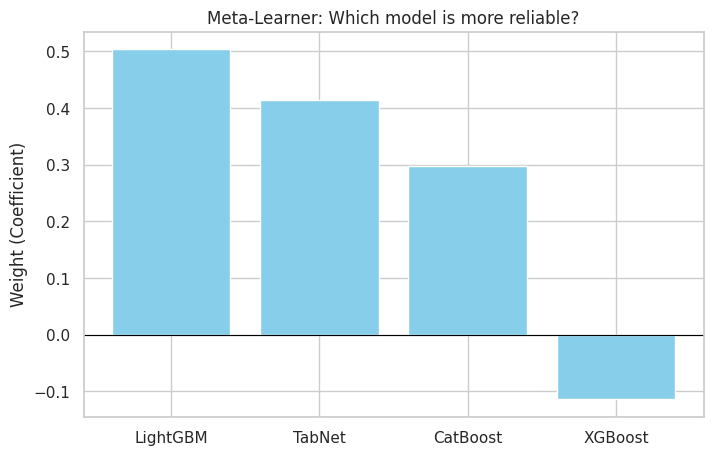

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 取得 Meta-Learner 的係數
weights = meta_learner.coef_
model_names = ['CatBoost', 'LightGBM', 'XGBoost', 'TabNet']

# 2. 建立 DataFrame 方便觀察
weight_df = pd.DataFrame({
    'Model': model_names,
    'Weight': weights
}).sort_values(by='Weight', ascending=False)

print(weight_df)

# 3. 畫圖
plt.figure(figsize=(8, 5))
plt.bar(weight_df['Model'], weight_df['Weight'], color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Meta-Learner: Which model is more reliable?')
plt.ylabel('Weight (Coefficient)')
plt.show()

In [ ]:
evaluate_model(y_test, y_pred_ensemble, "Meta-Learner Ensemble")

--- Meta-Learner Ensemble ---
MAE: 0.0893
MSE: 0.0124
R2 : 0.7653



(0.08927875560770263, 0.012398076686501868, 0.7653078239229654)

/tmp/ipykernel_34233/739160670.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x='Importance', y='Feature', ax=axes[i], palette='viridis')
/tmp/ipykernel_34233/739160670.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x='Importance', y='Feature', ax=axes[i], palette='viridis')
/tmp/ipykernel_34233/739160670.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x='Importance', y='Feature', ax=axes[i], palette='viridis')
/tmp/ipykernel_34233/739160670.py:29: FutureWarning: 

Passin

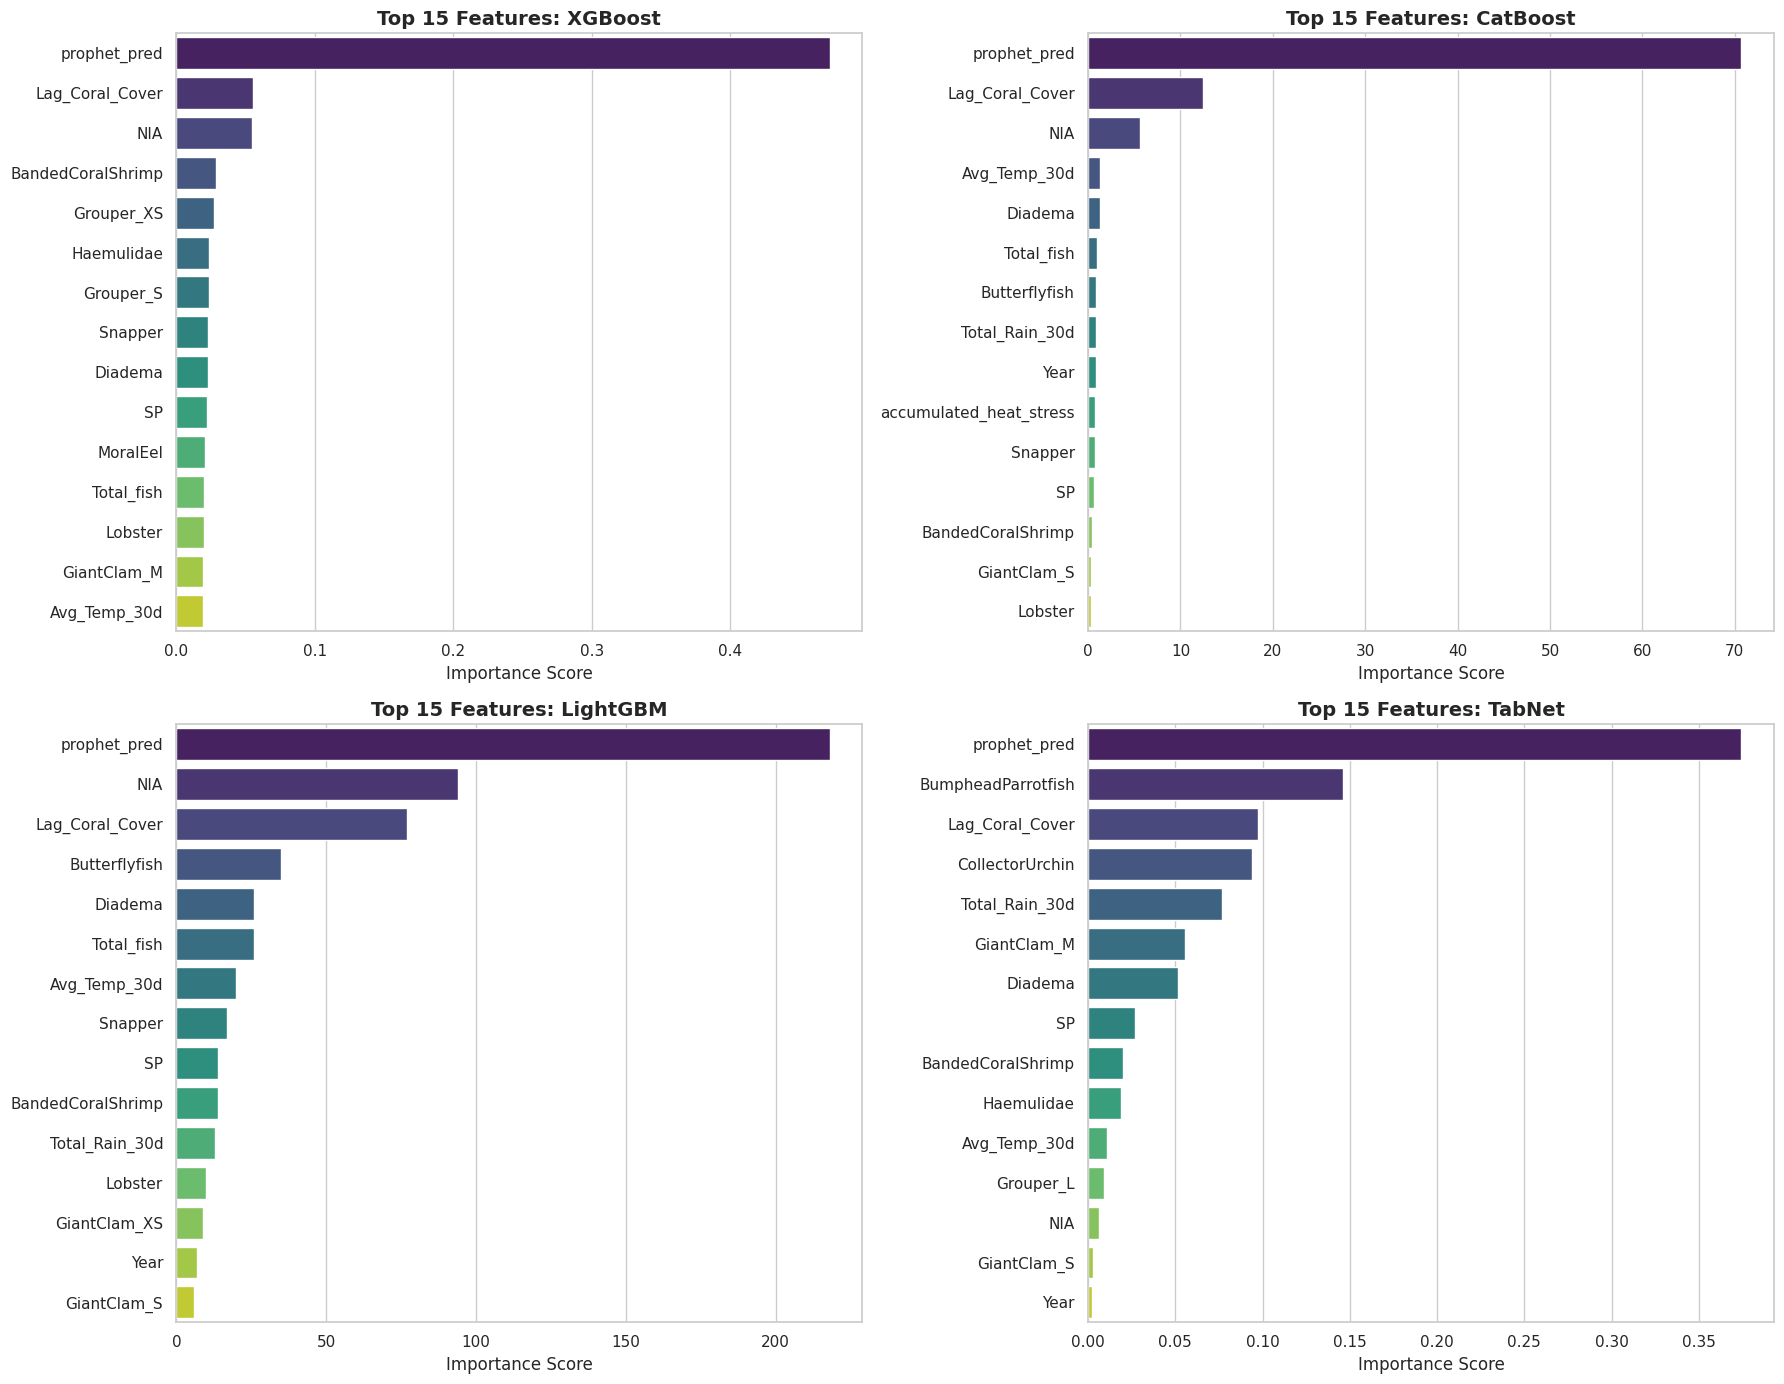

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_all_individual_importances(X_cols):
    # 定義模型清單與對應的提取方法
    models = {
        'XGBoost': grid_xgb.best_estimator_.feature_importances_,
        'CatBoost': grid_cat.best_estimator_.get_feature_importance(),
        'LightGBM': grid_lgbm.best_estimator_.feature_importances_,
        'TabNet': grid_tabnet.best_estimator_.feature_importances_
    }

    # 設定繪圖風格
    sns.set_theme(style="whitegrid")

    # 建立 2x2 的子圖佈局
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()

    for i, (name, importance) in enumerate(models.items()):
        # 建立該模型的 DataFrame 並排序
        df = pd.DataFrame({
            'Feature': X_cols,
            'Importance': importance
        }).sort_values(by='Importance', ascending=False)

        # 繪製橫向長條圖
        sns.barplot(data=df.head(15), x='Importance', y='Feature', ax=axes[i], palette='viridis')

        axes[i].set_title(f'Top 15 Features: {name}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Importance Score')
        axes[i].set_ylabel('')

    plt.tight_layout()
    plt.show()

# 執行繪圖 (假設您的特徵矩陣變數名為 X)
plot_all_individual_importances(X.columns)

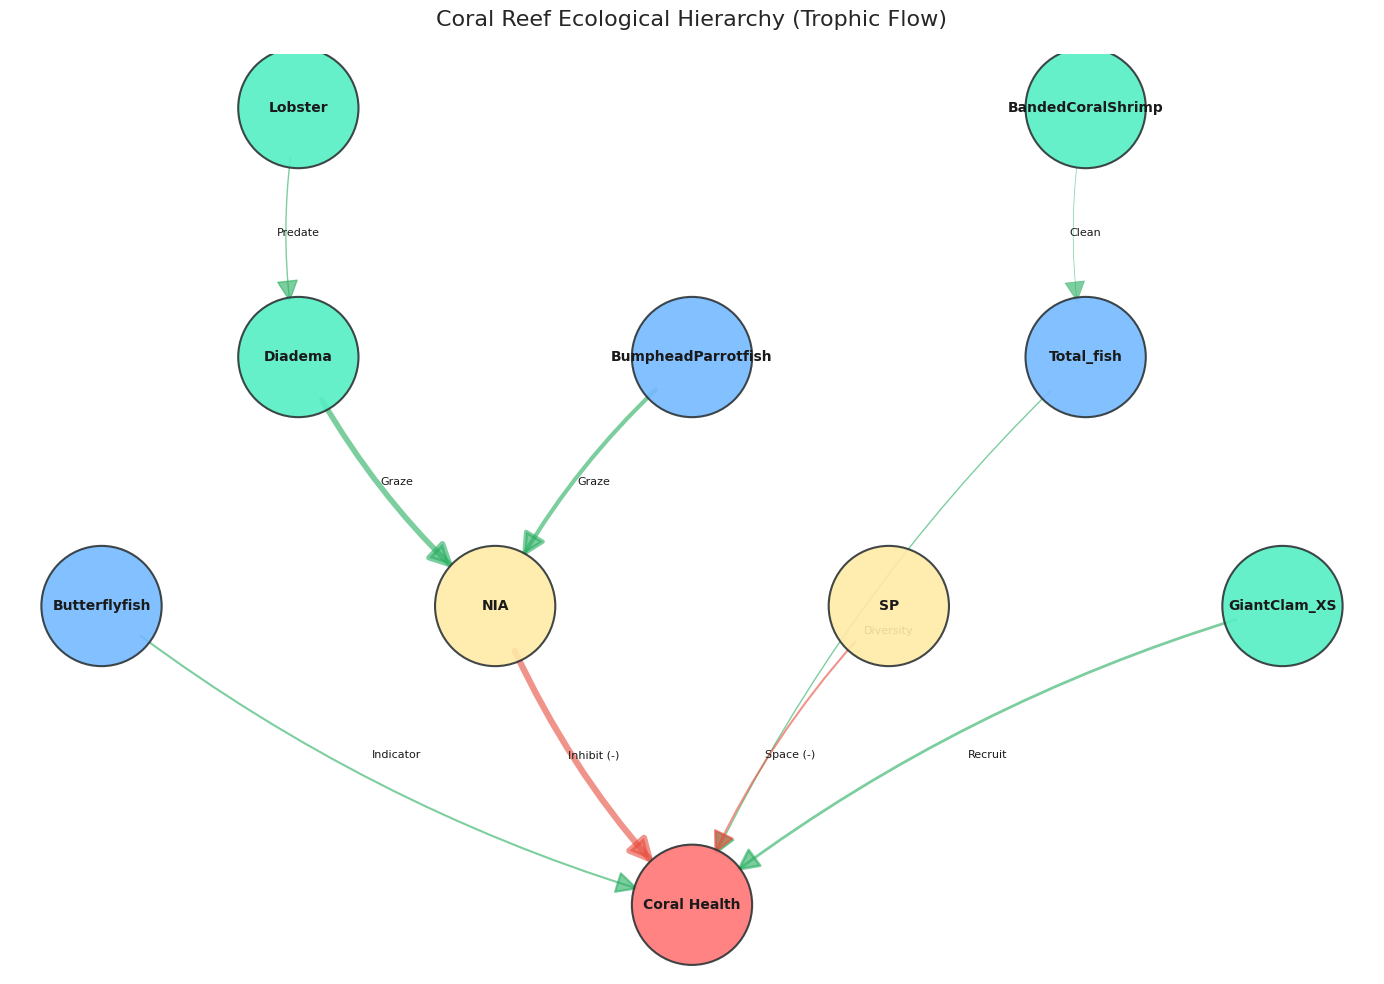

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. 準備權重數據
feature_names = ['Butterflyfish', 'BumpheadParrotfish', 'Total_fish',
                 'BandedCoralShrimp', 'Diadema', 'Lobster',
                 'GiantClam_XS', 'SP', 'NIA']
# 假設權重（正值對健康有益，負值為競爭）
weights = [0.15, 0.3, 0.1, 0.05, 0.4, 0.1, 0.2, -0.15, -0.45]
features = dict(zip(feature_names, weights))

G = nx.DiGraph()
target = "Coral Health"

# 2. 定義生態鏈關係
edges = [
    ('Lobster', 'Diadema', 'Predate'),
    ('BandedCoralShrimp', 'Total_fish', 'Clean'),
    ('Diadema', 'NIA', 'Graze'),
    ('BumpheadParrotfish', 'NIA', 'Graze'),
    ('NIA', target, 'Inhibit (-)'),
    ('SP', target, 'Space (-)'),
    ('Butterflyfish', target, 'Indicator'),
    ('GiantClam_XS', target, 'Recruit'),
    ('Total_fish', target, 'Diversity')
]

for src, dst, label in edges:
    w = abs(features.get(src, 0.1)) * 10
    G.add_edge(src, dst, weight=w, label=label)

# 3. 【手動座標調整】縮小範圍並讓佈局緊湊
# x 軸稍微收縮 (原本 0~10 改為更窄)，y 軸層次分明
pos = {
    'Lobster': (3, 4), 'BandedCoralShrimp': (7, 4),             # 頂層
    'Diadema': (3, 3), 'BumpheadParrotfish': (5, 3), 'Total_fish': (7, 3), # 中上層
    'Butterflyfish': (2, 2), 'NIA': (4, 2), 'SP': (6, 2), 'GiantClam_XS': (8, 2), # 中下層
    target: (5, 0.8)                                            # 底層核心
}

plt.figure(figsize=(14, 10))

# 4. 節點分類顏色
node_colors = []
for node in G.nodes:
    if node == target: node_colors.append('#ff7675') # 珊瑚
    elif node in ['NIA', 'SP']: node_colors.append('#ffeaa7') # 藻類/海綿
    elif 'fish' in node.lower() or node == 'BumpheadParrotfish': node_colors.append('#74b9ff') # 魚類
    else: node_colors.append('#55efc4') # 其他無脊椎

# 5. 繪製節點 (稍微縮小 size 配合緊湊佈局)
nx.draw_networkx_nodes(G, pos, node_size=7500, node_color=node_colors,
                       edgecolors='#2d3436', linewidths=1.5, alpha=0.9)

# 6. 繪製連線 (優化箭頭與邊距)
for u, v, d in G.edges(data=True):
    val = features.get(u, 0)
    # 決定顏色：正向影響綠色，負向影響紅色
    e_color = '#27ae60' if val >= 0 else '#e74c3c'

    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)],
                           width=d['weight'],
                           edge_color=e_color,
                           alpha=0.6,
                           arrowsize=35,
                           arrowstyle='-|>',
                           connectionstyle="arc3,rad=0.1",
                           min_source_margin=35,
                           min_target_margin=40)

# 7. 文字標籤 (精確置中，無白底)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# 8. 線條標籤 (【核心修正】移除背景方框)
edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                             font_size=8,
                             label_pos=0.5,
                             rotate=False,
                             bbox=dict(alpha=0)) # 透明背景

plt.title("Coral Reef Ecological Hierarchy (Trophic Flow)", fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 假設你的 y_pred_ensemble 是最後的整合預測結果
# 假設你的 df_selected 是還沒 drop 'Site' 之前的完整 DataFrame

# 1. 建立結果對照表 (確保 Index 對齊)
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_ensemble
}, index=y_test.index)

# 2. 從原始資料中抓回 Site 和 Date 資訊
# 註：df_selected 是你在合併 Latitude/Longitude 後的那個 DataFrame
results_df['Site'] = data.loc[y_test.index, 'Site']
results_df['Date'] = pd.to_datetime(data.loc[y_test.index, 'Date'], format='%Y%m%d')

# 依日期排序，這樣折線圖才會按時間走
results_df = results_df.sort_values(by=['Site', 'Date'])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_site_results(results_df, site_name):
    """
    指定地區畫出預測與實際值的對照圖
    """
    # 篩選特定地區
    site_data = results_df[results_df['Site'] == site_name]

    if site_data.empty:
        print(f"找不到地區: {site_name}，請檢查名稱是否正確。")
        return

    plt.figure(figsize=(12, 6))

    # 畫出實際值與預測值
    sns.lineplot(data=site_data, x='Date', y='Actual', label='Actual (HC+SC+RKC)', marker='o', linewidth=2)
    sns.lineplot(data=site_data, x='Date', y='Predicted', label='Predicted (Ensemble)', marker='x', linestyle='--', linewidth=2)

    plt.title(f'Prediction Performance at: {site_name}', fontsize=15)
    plt.xlabel('Survey Date', fontsize=12)
    plt.ylabel('Coral Cover (HC + SC + RKC)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 檢查一下有哪些地區可以選
print("可選地區列表:", results_df['Site'].unique())

可選地區列表: ['BeautyCave' 'BeautyRock' 'BiTou' 'ChaiKou' 'FanCaiao' 'GiHaw' 'GongGuan'
 'HeChei' 'HenRock' 'JiangJunYan' 'LongDong1.5' 'LongDong4' 'ShanYuan'
 'ShiLang' 'ShiTiPing' 'TurtleBay' 'YeLiu' 'YuChenWei']


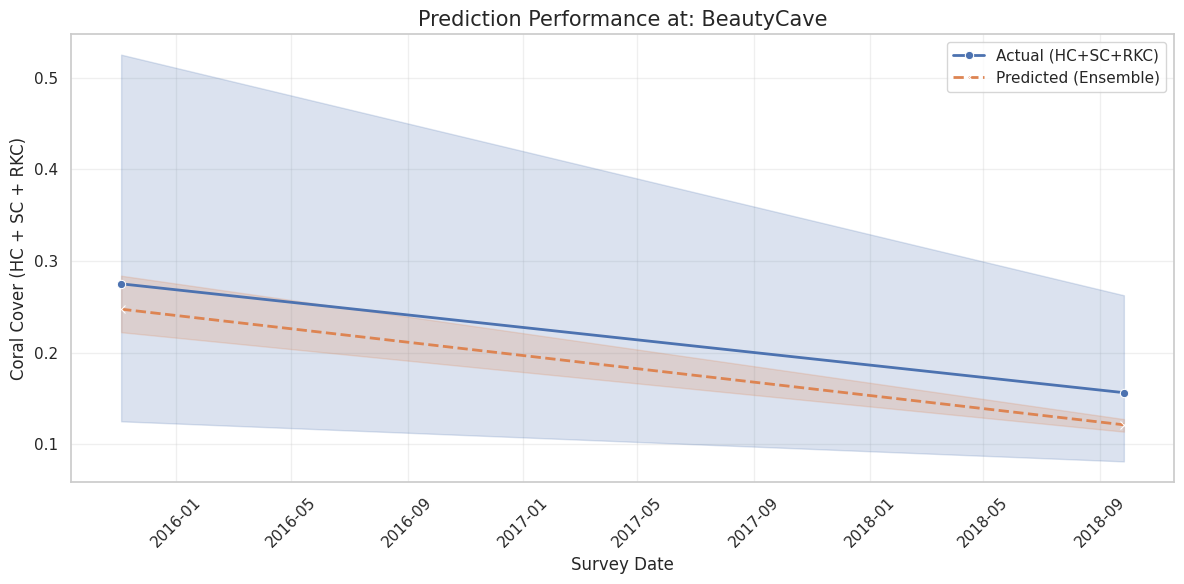

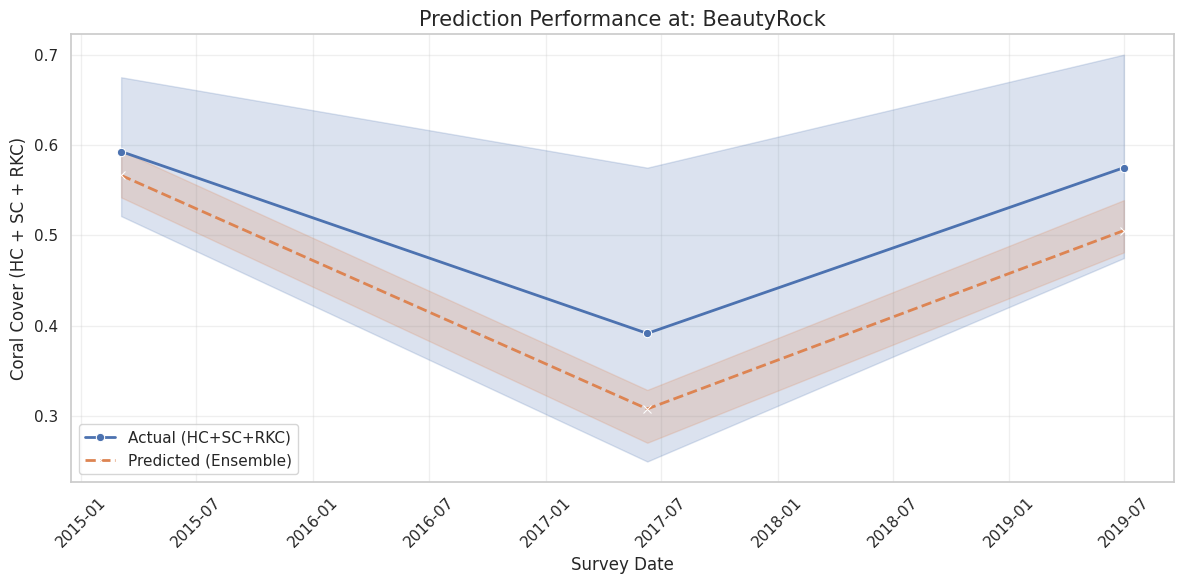

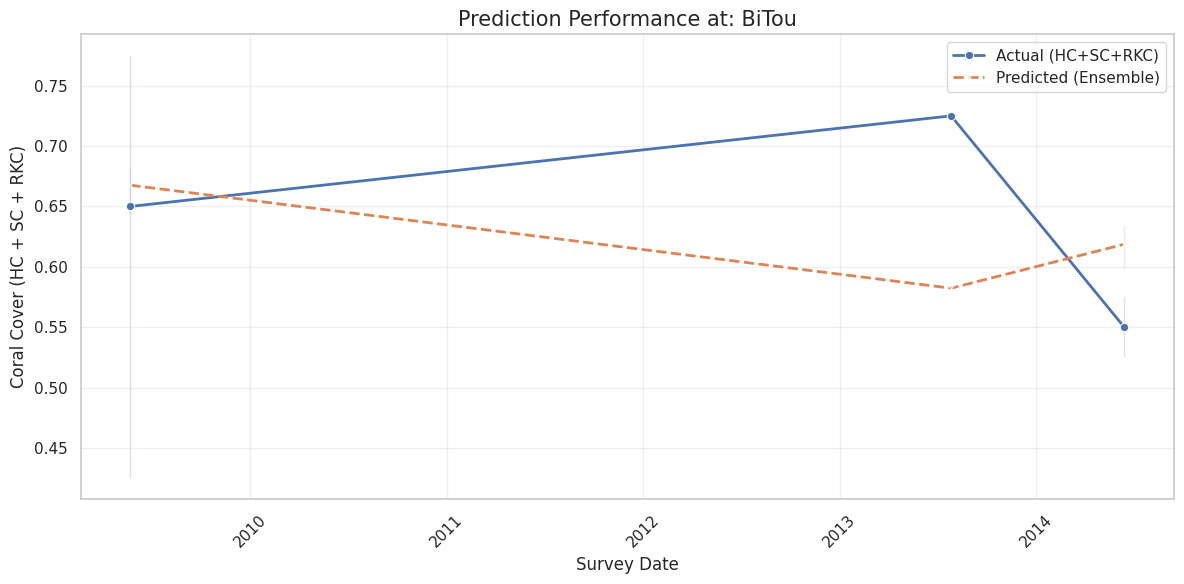

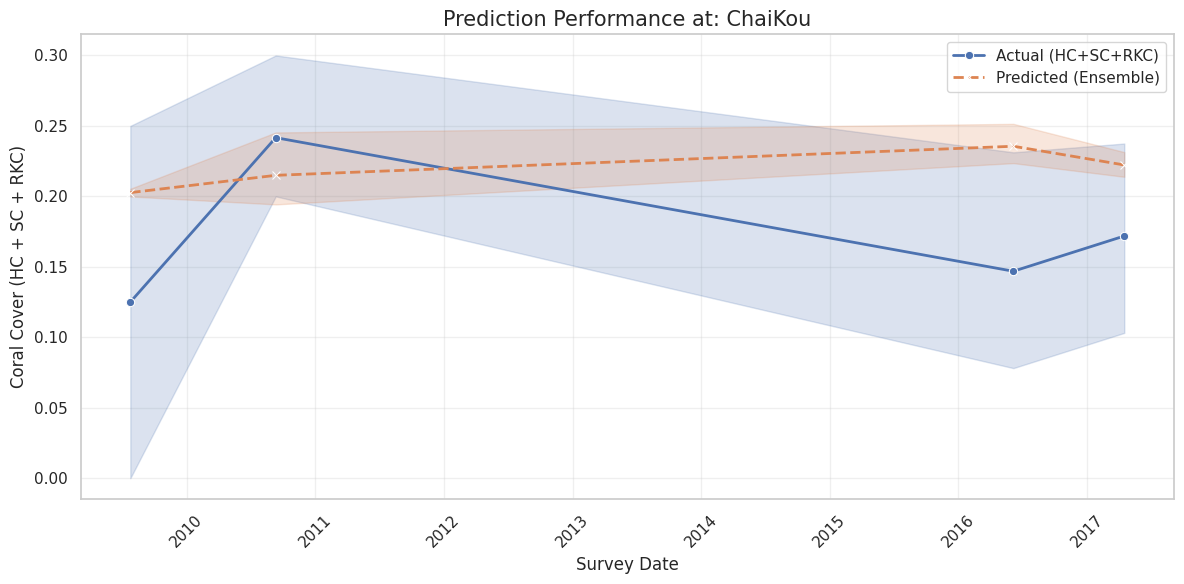

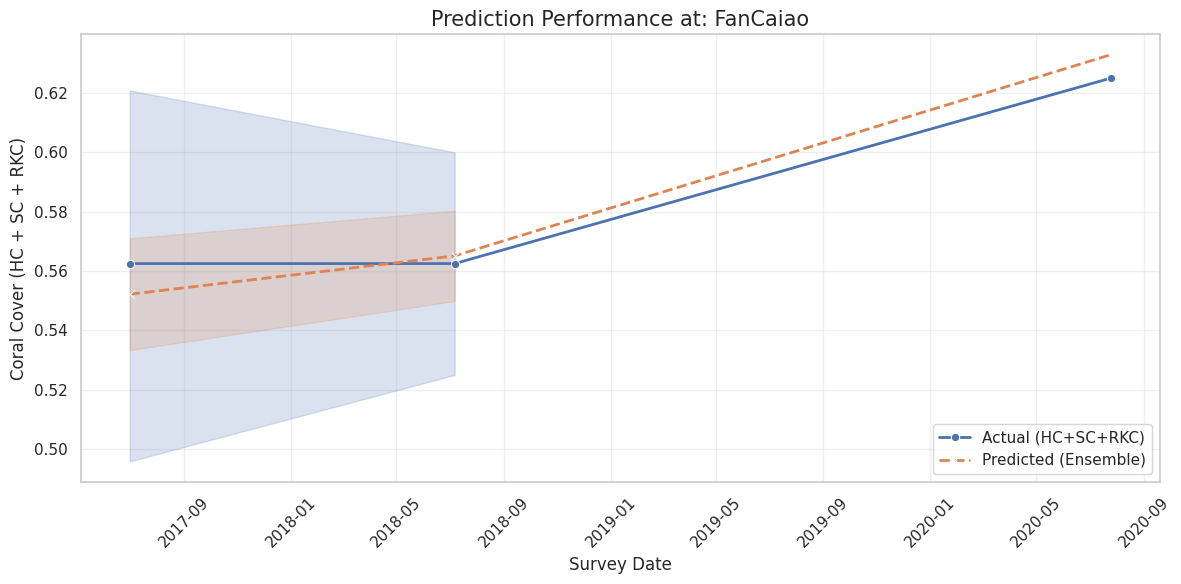

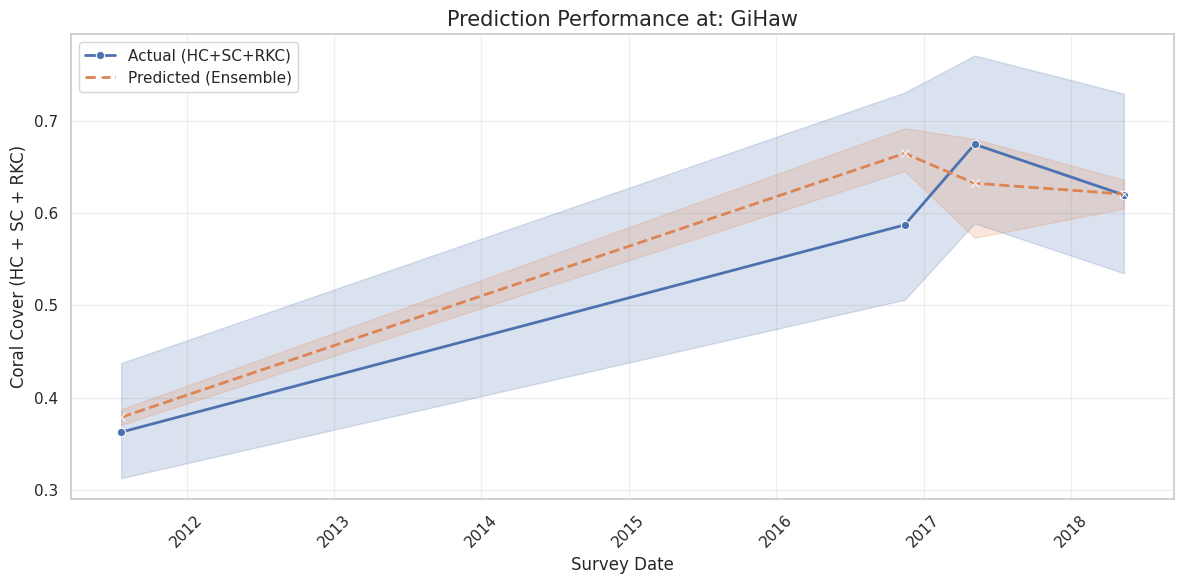

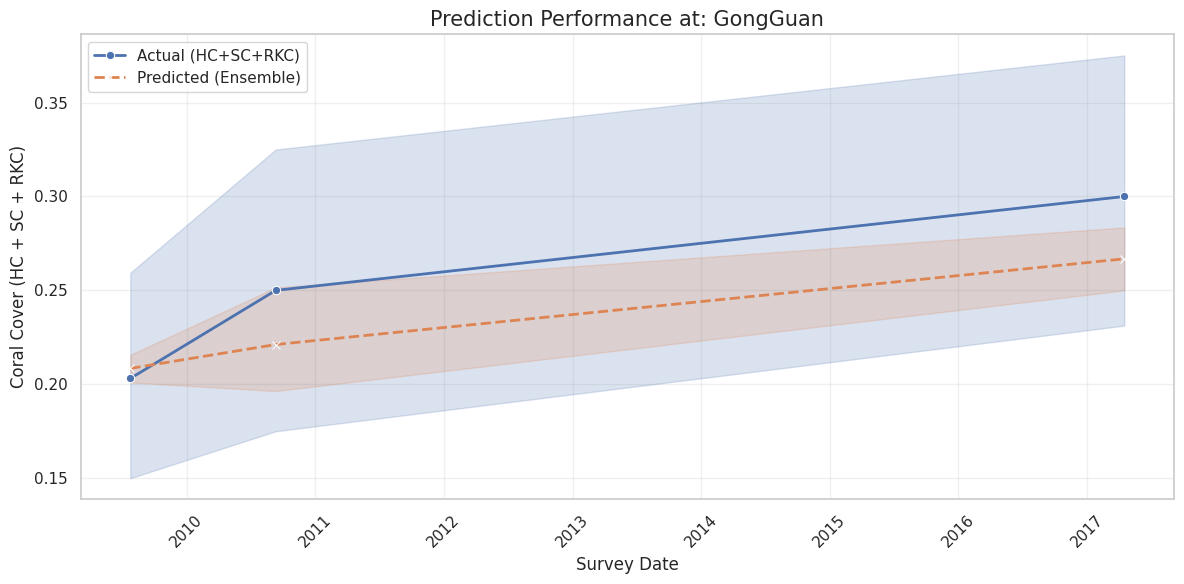

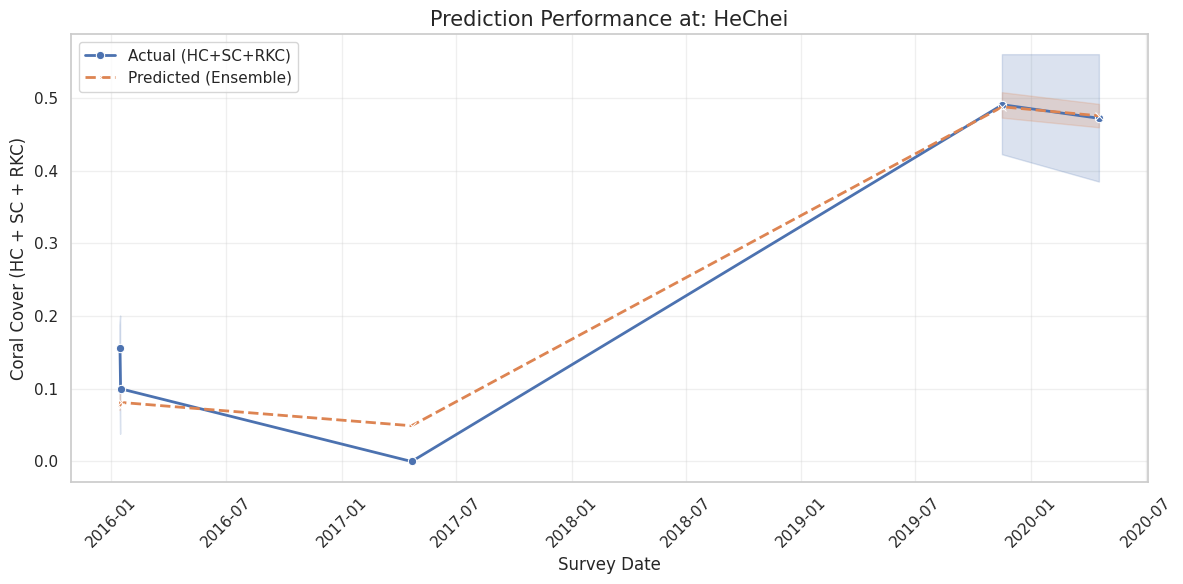

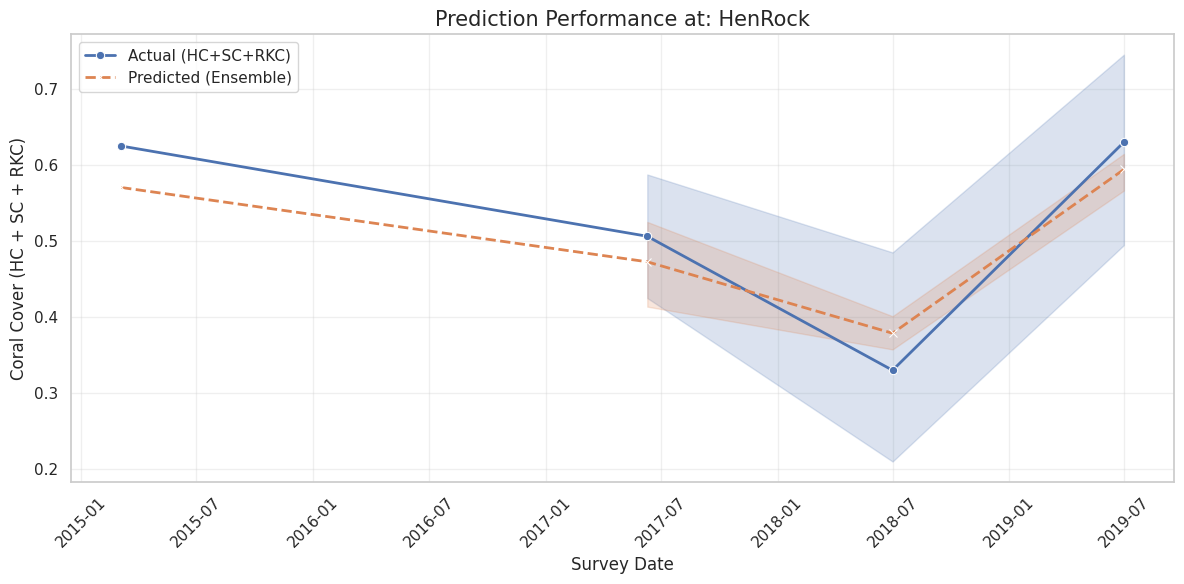

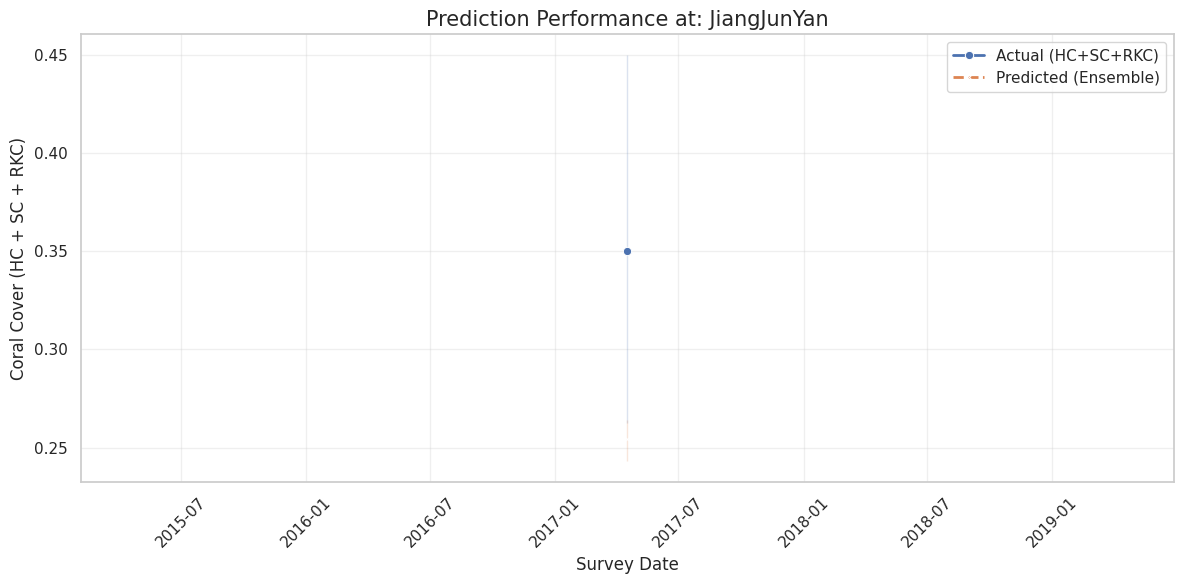

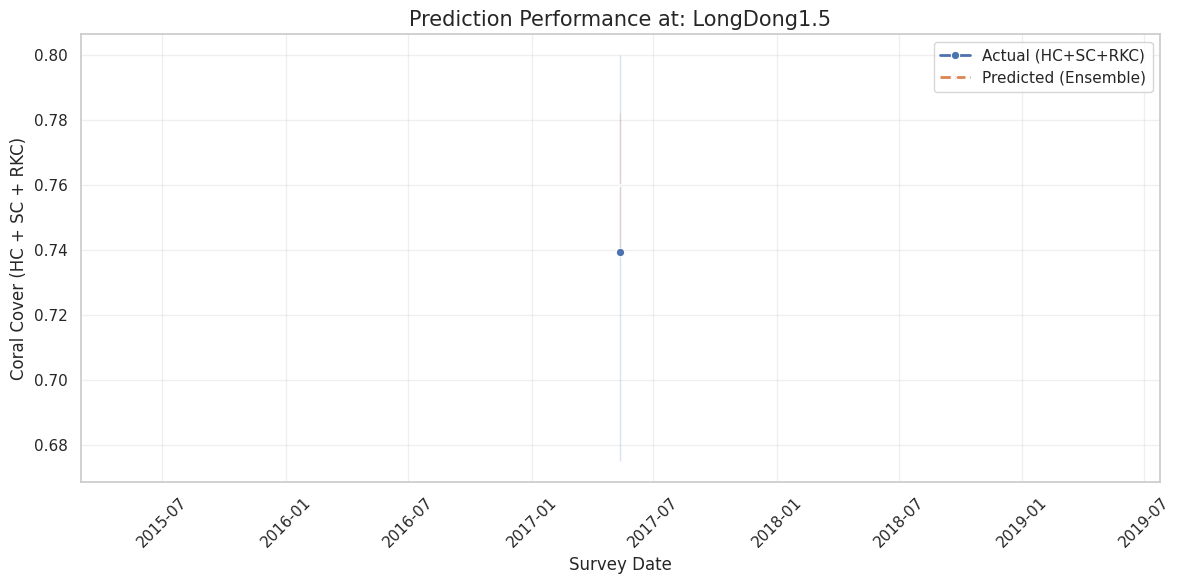

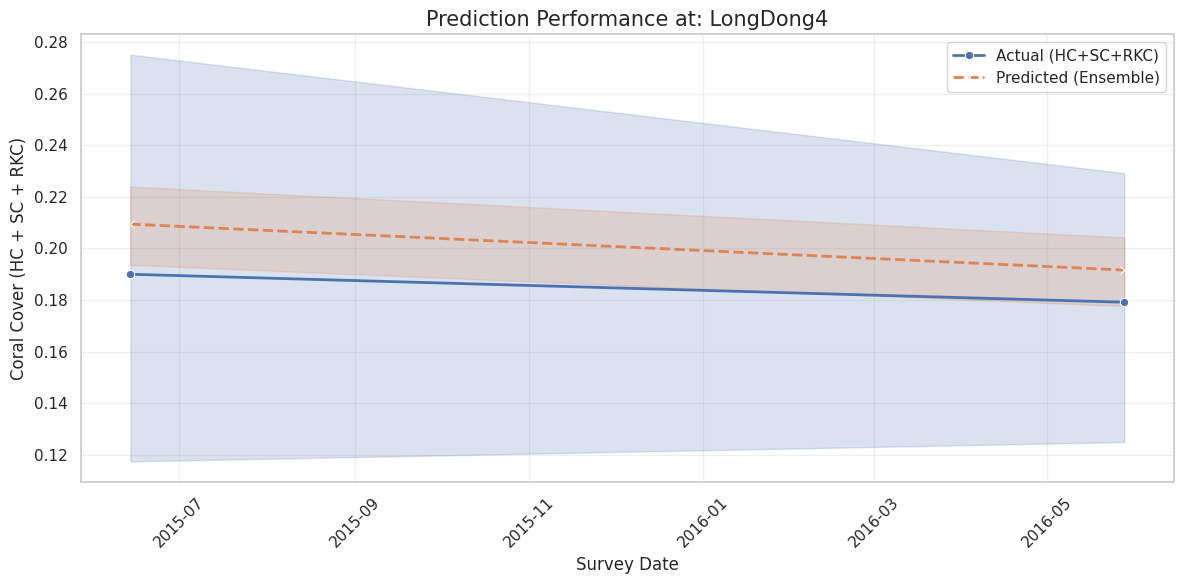

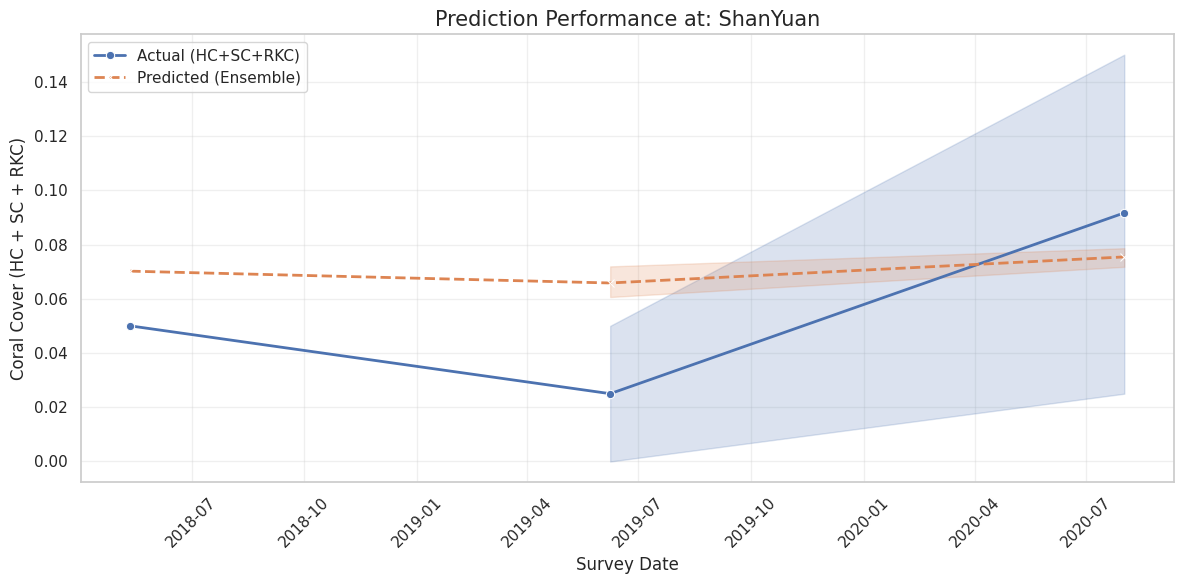

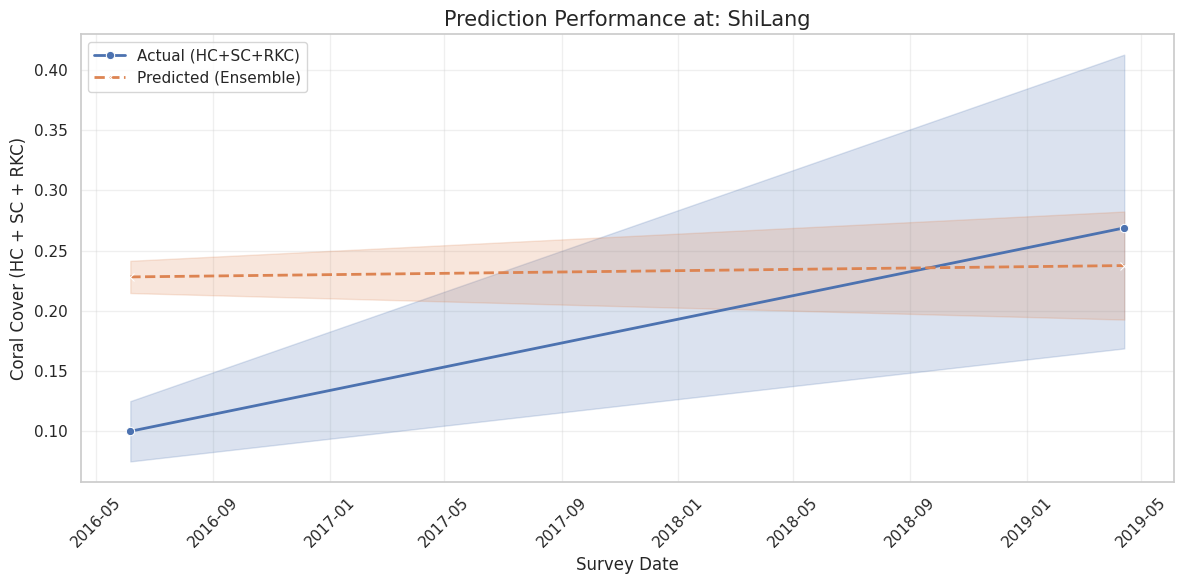

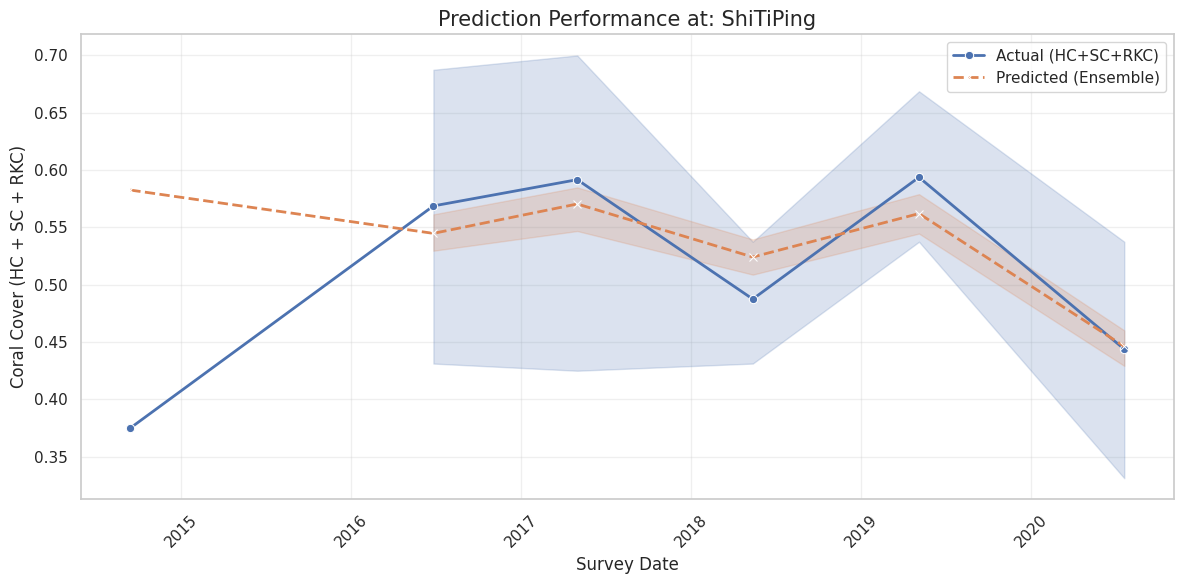

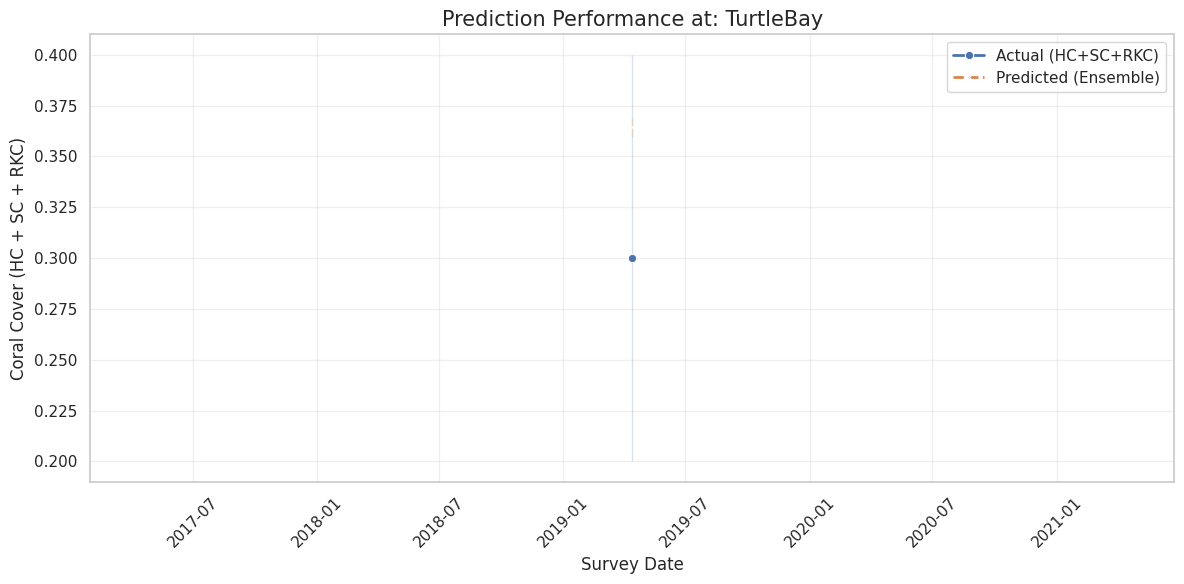

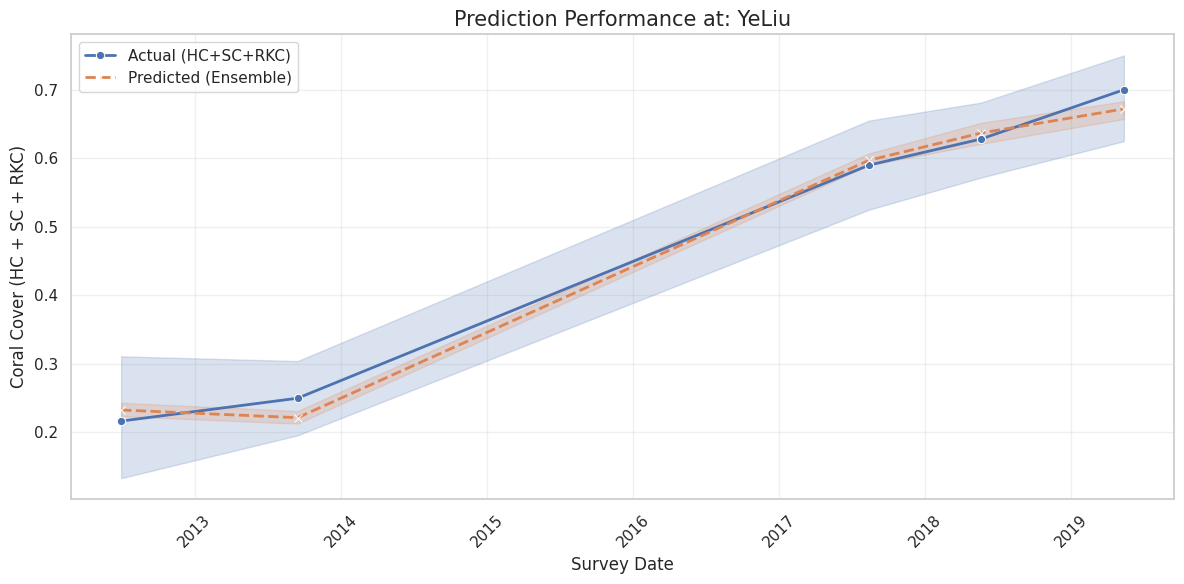

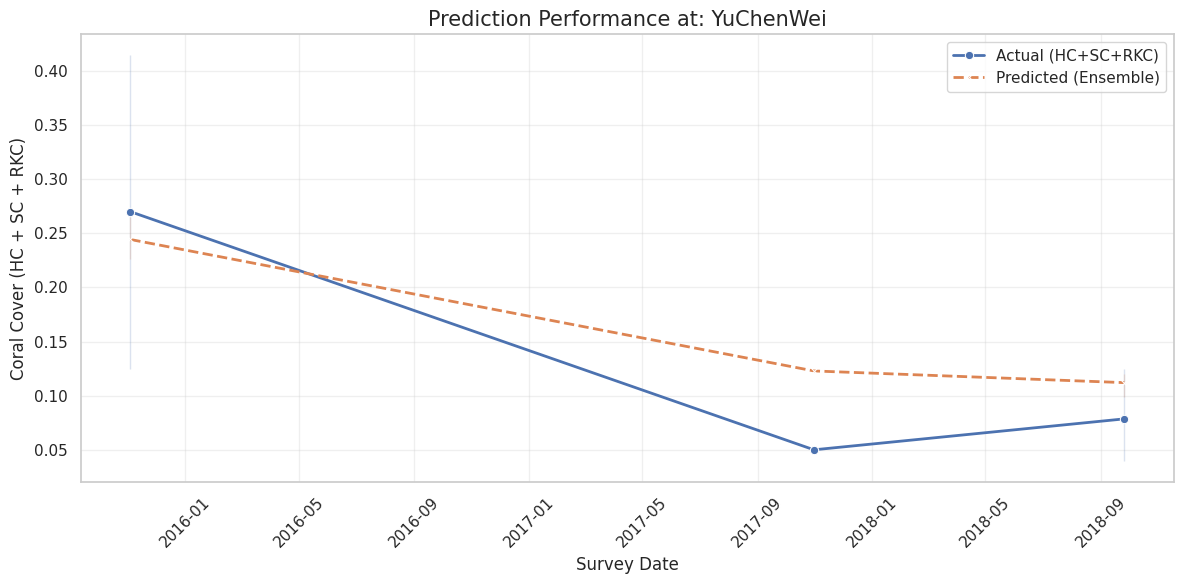

In [ ]:
# 範例：查看 "綠島大香菇" 的結果 (請替換成你資料中實際有的 Site 名稱)
for i in range(len(results_df['Site'].unique())):
  target_site = results_df['Site'].unique()[i]
  plot_site_results(results_df, target_site)